# GCAP3226 Week 4 — In-class exercise (5%)

**Individual.** Three tasks + submit (Commit & Push → Moodle GitHub URL).

| Task | Do this |
|------|---------|
| **1** | Percentage change by A&E triage; largest fall / rise; triage 4+5 combined |
| **2** | Grouped bar chart: H1 2025 vs H1 2026 attendances by triage (10 bars) + numbers / percentage change |
| **3** | Short write-up: one supporting point + one gap for the A&E claim |


## Setup

Run the next cell. Data: `w4_ae_triage_h1.csv` (**H1** 2025 vs **H1** 2026 attendances by triage).

**H1** = first half of the year (usually **1 January – 30 June**).

**AI:** `Cmd+I` / `Ctrl+I` on a code cell → implement the comment prompt → **Keep**. Interpretations in your own words.


In [3]:
# Setup — run first
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_FILE = "week4_ae_triage_h1.csv"
path = Path(DATA_FILE) if Path(DATA_FILE).is_file() else Path.cwd() / DATA_FILE
df = pd.read_csv(path)
print("Using:", path.resolve())
df



Using: /workspaces/GCAP3226_week4/week4_ae_triage_h1.csv


,triage,triage_name,attend_h1_2025,attend_h1_2026
0,1,Critical,13848,14541
1,2,Emergency,28554,29981
2,3,Urgent,400428,411994
3,4,Semi-urgent,489032,441974
4,5,Non-urgent,18448,14758


## Task 1 — Percentage change

**Purpose:** Measure how A&E attendances changed from H1 2025 to H1 2026 for each triage group, so you can see which groups rose or fell before judging the A&E claim in Task 3.

1. Add a column `pct_change` = `(attend_h1_2026 - attend_h1_2025) / attend_h1_2025 * 100`.
2. Show the table.
3. Print the triage with the **largest fall** and the **largest rise**.
4. Compute the percentage change for triage **4+5 combined** (sum attendances first, then apply the same formula).

Then, in the next cell, write **1–2 sentences** answering:
- Did triage **1–2** (Critical / Emergency) mainly **rise or fall**?
- Did triage **4–5** (Semi-urgent / Non-urgent) mainly **rise or fall**?
- In one short phrase: what does that pattern look like for the A&E claim (lower-urgency down; critical/emergency protected)?


In [4]:
# Task 1
#
# Input: df (triage, triage_name, attend_h1_2025, attend_h1_2026)
# Process: Write Python code to add pct_change, display the table,
#          print largest fall and largest rise; also 4+5 combined percentage change
# Output: table + printed fall/rise + 4+5 combined
#
# YOUR CODE BELOW
# Task 1
df["pct_change"] = (
    (df["attend_h1_2026"] - df["attend_h1_2025"]) /
    df["attend_h1_2025"] * 100
)

print(df[["triage", "triage_name", "attend_h1_2025", "attend_h1_2026", "pct_change"]])

largest_fall = df.loc[df["pct_change"].idxmin()]
largest_rise = df.loc[df["pct_change"].idxmax()]

print("\nLargest fall:")
print(largest_fall[["triage", "triage_name", "pct_change"]])

print("\nLargest rise:")
print(largest_rise[["triage", "triage_name", "pct_change"]])

# Triage 4+5 combined
t45_2025 = df[df["triage"].isin([4, 5])]["attend_h1_2025"].sum()
t45_2026 = df[df["triage"].isin([4, 5])]["attend_h1_2026"].sum()

t45_pct_change = ((t45_2026 - t45_2025) / t45_2025) * 100



   triage  triage_name  attend_h1_2025  attend_h1_2026  pct_change
0       1     Critical           13848           14541    5.004333
1       2    Emergency           28554           29981    4.997549
2       3       Urgent          400428          411994    2.888409
3       4  Semi-urgent          489032          441974   -9.622683
4       5   Non-urgent           18448           14758  -20.002168

Largest fall:
triage                  5
triage_name    Non-urgent
pct_change     -20.002168
Name: 4, dtype: object

Largest rise:
triage                1
triage_name    Critical
pct_change     5.004333
Name: 0, dtype: object


In [5]:
# Task 1 note
task1_note = """
Triage 1–2 mainly rose, while triage 4–5 mainly fell. This matches the A&E claim that lower-urgency attendances dropped while critical/emergency care stayed protected.
"""
print(task1_note)




Triage 1–2 mainly rose, while triage 4–5 mainly fell. This matches the A&E claim that lower-urgency attendances dropped while critical/emergency care stayed protected.



## Task 2 — Visualization

**Purpose:** Turn the Task 1 table into a **grouped bar chart** that compares H1 2025 and H1 2026 attendances for each triage (5 groups, 2 bars each → 10 bars), and makes the **numbers** and **percentage change** easy to see.

In the next code cell, write your own IPO comment prompt, then use Inline Chat to implement it. Interpretations stay in your own words.


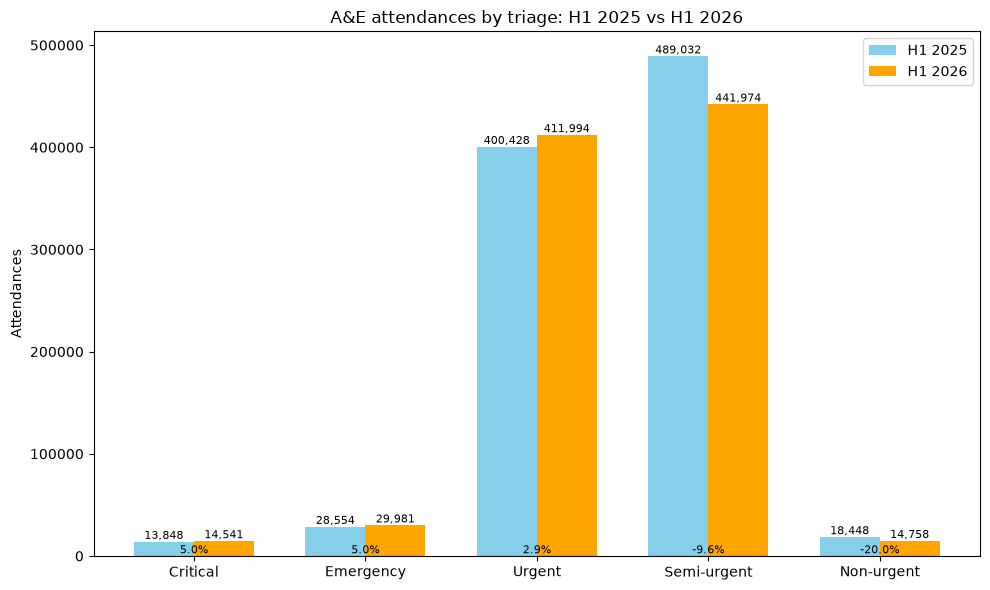

In [7]:
# Task 2 — write your own IPO prompt in the comments, then use Inline Chat
#
# Input:
#
# Process:
#   Write Python code to ...
#
# Output:
#
# YOUR CODE BELOW
# Task 2 - grouped bar chart
import matplotlib.pyplot as plt
import numpy as np

# Keep the Task 1 pct_change column already created
df = df.sort_values("triage").reset_index(drop=True)

x = np.arange(len(df))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, df["attend_h1_2025"], width,
               label="H1 2025", color="skyblue")
bars2 = ax.bar(x + width/2, df["attend_h1_2026"], width,
               label="H1 2026", color="orange")

ax.set_xticks(x)
ax.set_xticklabels(df["triage_name"], rotation=0)
ax.set_ylabel("Attendances")
ax.set_title("A&E attendances by triage: H1 2025 vs H1 2026")
ax.legend()

# Add numbers above each bar
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 200,
                f"{int(h):,}", ha="center", va="bottom", fontsize=8)

# Add percentage change labels under/near bars
for i, row in df.iterrows():
    pct = row["pct_change"]
    ax.text(i, 0, f"{pct:.1f}%", ha="center", va="bottom", fontsize=8, color="black")

plt.tight_layout()



## Task 3 — Write-up

**Claim:** After fee reform, A&E improved — lower-urgency attendances fell; critical/emergency care stayed protected; urgent care became more efficient.

You may also cite: triage III within 30 min **81.4 → 88.5** (percentage); mean wait **23 → 20** min.

**3a** — Write **one supporting point** (cite a number) and **one gap** in the evidence.

**3b** — 2–4 sentences: how well is the claim supported by the published evidence (your table / chart, and any figures cited above)?


In [9]:
# Task 3
task3a = """
3a SUPPORT (1 point, cite a number):
The chart shows lower-urgency attendances fell, with triage 4 decreasing from 489,032 to 441,974 (−9.6%) and triage 5 from 18,448 to 14,758 (−20.0%).
3a GAP (1 point):
The evidence is suggestive but not conclusive, because it does not prove the fee reform alone caused the pattern.
"""

task3b = """
3b:     
The chart shows a clear pattern consistent with the claim: lower-urgency A&E attendances fell, while triage 1 and 2 remained stable or increased, suggesting that more serious cases were still protected. This is partly supported by the published evidence, which also reports improved urgent care performance, such as triage III within-30-minute performance rising from 81.4% to 88.5%. However, the evidence is still not conclusive because it does not prove the fee reform alone caused the change. Overall, the claim is reasonably supported by the pattern in the data, but more direct evidence would be needed to establish causation.
"""

print(task3a)
print("---")
print(task3b)




3a SUPPORT (1 point, cite a number):
The chart shows lower-urgency attendances fell, with triage 4 decreasing from 489,032 to 441,974 (−9.6%) and triage 5 from 18,448 to 14,758 (−20.0%).
3a GAP (1 point):
The evidence is suggestive but not conclusive, because it does not prove the fee reform alone caused the pattern.

---

3b:     
The chart shows a clear pattern consistent with the claim: lower-urgency A&E attendances fell, while triage 1 and 2 remained stable or increased, suggesting that more serious cases were still protected. This is partly supported by the published evidence, which also reports improved urgent care performance, such as triage III within-30-minute performance rising from 81.4% to 88.5%. However, the evidence is still not conclusive because it does not prove the fee reform alone caused the change. Overall, the claim is reasonably supported by the pattern in the data, but more direct evidence would be needed to establish causation.



## Submit

1. Save → Source Control → **Commit & Push**  
2. Moodle: paste your **GitHub URL**
